In [117]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
import operator
from langchain_core.messages import (HumanMessage,SystemMessage)

In [118]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


In [119]:
class EvaluateTweet(BaseModel):
    evaluation: Literal["approved","rejected"] = Field(...,description="Whether the tweet is approved or rejected")
    feedback: str = Field(...,description="Constructive feedback for the tweet")

In [120]:
#llama-3.3-70b-versatile
generate_tweet = ChatGroq(model="llama-3.3-70b-versatile",temperature=0.7)

# qwen/qwen3-32b
evaluate_tweet_qwen = ChatGroq(model="qwen/qwen3-32b",temperature=0.7)

structred_evaluate_tweet = evaluate_tweet_qwen.with_structured_output(EvaluateTweet)

optimize_tweet = ChatGroq(model="llama-3.3-70b-versatile",temperature=0.7)

In [121]:
# structred_evaluate_tweet.invoke("The future of AI in everyday life")

In [122]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved","rejected"]
    feedback: str
    iteration: int
    max_iterations: int

In [123]:
def generate_tweet_node(state:TweetState):
    messages = [
        SystemMessage(
            content=(
                "You are an expert Twitter ghostwriter. "
                "Write a tweet with at least 1000 characters. "
                "No hashtags unless extremely necessary. "
                "No emojis unless they add meaning. "
                "Be original, witty, and impactful."
            )
        ),
        HumanMessage(content=f"Topic: {state['topic']}\nGenerate one tweet.")
    ]

    response = generate_tweet.invoke(messages)
    tweet = response.content
    print(f"Generated Tweet: {tweet}")

    return {"tweet": tweet}

In [124]:
def structured_evaluate_tweet_node(state: TweetState) :
    """
    Evaluates the generated tweet using Qwen structured output.
    """
    system_prompt = (
        "You are a strict expert tweet evaluator. Your job is to judge the tweet's clarity, "
        "engagement, originality, and relevance to the topic. If the tweet is weak, mark it as "
        "'rejected' and provide clear, actionable feedback. If it is strong, mark it as 'approved' "
        "and give a positive justification."
    )

    user_prompt = (
        f"Topic: {state['topic']}\n"
        f"Tweet: {state['tweet']}\n"
        "Evaluate the tweet."
    )

    result= structred_evaluate_tweet.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])

    print(f"Evaluation: {result.evaluation}\nFeedback: {result.feedback}")

    # return updated state
    return {
        "evaluation": result.evaluation,
        "feedback": result.feedback
    }

In [125]:
def optimize_tweet_node(state:TweetState):
    """
    Optimizes the tweet based on feedback using LLaMA.
    """
    system_prompt = (
        "You are a skilled tweet optimizer. Your task is to improve the given tweet based on the feedback. "
        "Make the tweet more engaging, clear, and relevant to the topic and at least in 1000 words."
    )

    user_prompt = (
        f"Topic: {state['topic']}\n"
        f"Current Tweet: {state['tweet']}\n"
        f"Feedback: {state['feedback']}\n"
        "Optimize the tweet."
    )

    response = optimize_tweet.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])

    optimized_tweet = response.content.strip()
    state['iteration'] += 1

    print(f"Optimized Tweet: {optimized_tweet}")

    return {"tweet": optimized_tweet , "iteration": state['iteration']}

In [126]:
def route_evaluation(state:TweetState):
    """
    Routes the workflow based on the evaluation result.
    If approved, go to END. If rejected, go back to optimization (if max iterations not reached) or END.
    """
    if state["evaluation"] == "approved":
        return "approved"
    elif state["iteration"] >= state["max_iterations"]:
        return "approved"
    else:
        return "rejected"

In [127]:
graph = StateGraph(TweetState)

graph.add_node("generate_tweet",generate_tweet_node)
graph.add_node("evaluate_tweet",structured_evaluate_tweet_node)
graph.add_node("optimize_tweet",optimize_tweet_node)

graph.add_edge(START , "generate_tweet")
graph.add_edge("generate_tweet","evaluate_tweet")

graph.add_conditional_edges("evaluate_tweet", route_evaluation, {"approved": END, "rejected": "optimize_tweet"})

graph.add_edge("optimize_tweet","evaluate_tweet")

workflow = graph.compile()

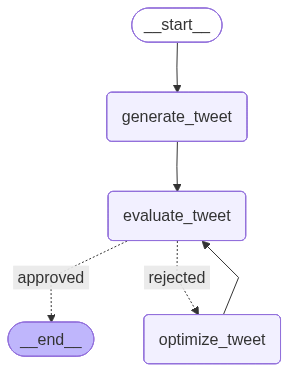

In [128]:
workflow

In [129]:
initial_state = {
    "topic": "The future of AI in everyday life",
    "iteration": 1,
    "max_iterations": 3
}

workflow.invoke(initial_state)

Generated Tweet: As we stand at the threshold of a new era in artificial intelligence, it's becoming increasingly clear that the future of AI in everyday life will be shaped by its ability to seamlessly integrate into our daily routines, from intelligent personal assistants that learn our habits and preferences, to smart homes that anticipate our needs and adapt to our lifestyles, and self-driving cars that redefine the concept of transportation, all of which will undoubtedly raise important questions about the impact of AI on employment, privacy, and social inequality, but one thing is certain, the future of AI will be characterized by its potential to augment human capabilities, freeing us from mundane tasks and empowering us to focus on more creative and meaningful pursuits, and as we embark on this journey, it's essential that we prioritize transparency, accountability, and ethics in AI development, ensuring that the benefits of AI are equitably distributed and its risks are mitiga

{'topic': 'The future of AI in everyday life',
 'tweet': "**The Future of AI in Everyday Life: A New Era of Possibilities**\n\nAI will automate 85% of your daily tasks by 2030—should we be excited or worried? 🤖 Imagine a world where intelligent personal assistants learn your habits and preferences, anticipating your needs and making your life easier. But what does this mean for us, and how will it impact our daily lives? Here are a few key points to consider:\n\n* 🚗 Self-driving cars will redefine the concept of transportation, reducing accidents and increasing mobility for the elderly and disabled.\n* 🏠 Smart homes will be equipped with sensors and automated systems that will adjust lighting, temperature, and security settings to create a comfortable and safe living space.\n* 📊 But as AI takes over routine tasks, there is a risk that many jobs will become obsolete—what new opportunities will emerge, and how can we prepare for the changing job market?\n\nWhat’s YOUR biggest hope/concer